In [11]:
import funcs
import importlib

# Prépartion du dataset

In [12]:
path_data = 'data/source/images/'
path_data_save = 'data/cleaned/images/'
infos = funcs.get_filenames_labels_and_count(path_data)
funcs.display_n_images_per_class(infos)

,Maltese dog,Afghan hound,Scottish deerhound,Pomeranian,Samoyed,Bernese mountain dog,Irish wolfhound,Shih-Tzu,Great Pyrenees,Leonberg,...,affenpinscher,kuvasz,Eskimo dog,groenendael,malinois,Border collie,Doberman,Welsh springer spaniel,Pekinese,redbone
Nombre d'images,252,239,232,219,218,218,218,214,213,210,...,150,150,150,150,150,150,150,150,149,148


Nombre de classes: 120
Nombre total d'images: 20580
Nombre de classes conservées: 10
Nombre total d'images: 2233


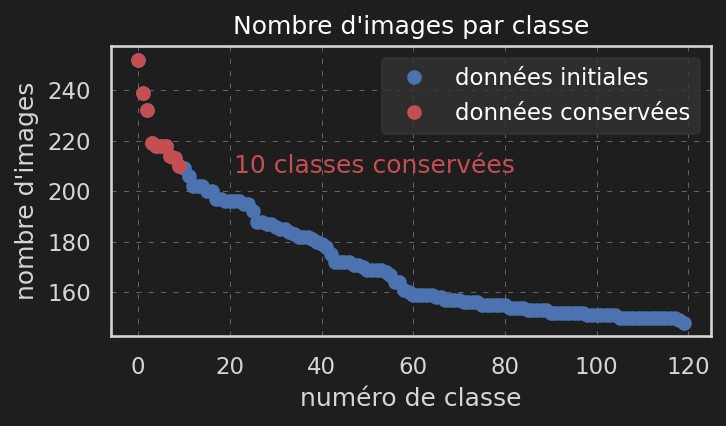

In [13]:
n_kept_classes = 10
funcs.plot_classes(infos, n_kept_classes)

In [14]:
funcs.get_kept_classes_and_folders(infos, path_data, n_kept_classes)
display(infos['df kept classes'])

,folder,n images
Maltese dog,n02085936-Maltese_dog,252
Afghan hound,n02088094-Afghan_hound,239
Scottish deerhound,n02092002-Scottish_deerhound,232
Pomeranian,n02112018-Pomeranian,219
Samoyed,n02111889-Samoyed,218
Bernese mountain dog,n02107683-Bernese_mountain_dog,218
Irish wolfhound,n02090721-Irish_wolfhound,218
Shih-Tzu,n02086240-Shih-Tzu,214
Great Pyrenees,n02111500-Great_Pyrenees,213
Leonberg,n02111129-Leonberg,210


In [15]:
funcs.read_image_shapes(path_data, infos)

Nombre d'images en noir et blanc 0


Nombre d'images: 2233
Nombre de largeurs différentes: 225
Nombre de hauteurs différentes: 283
i,j max: 140 190


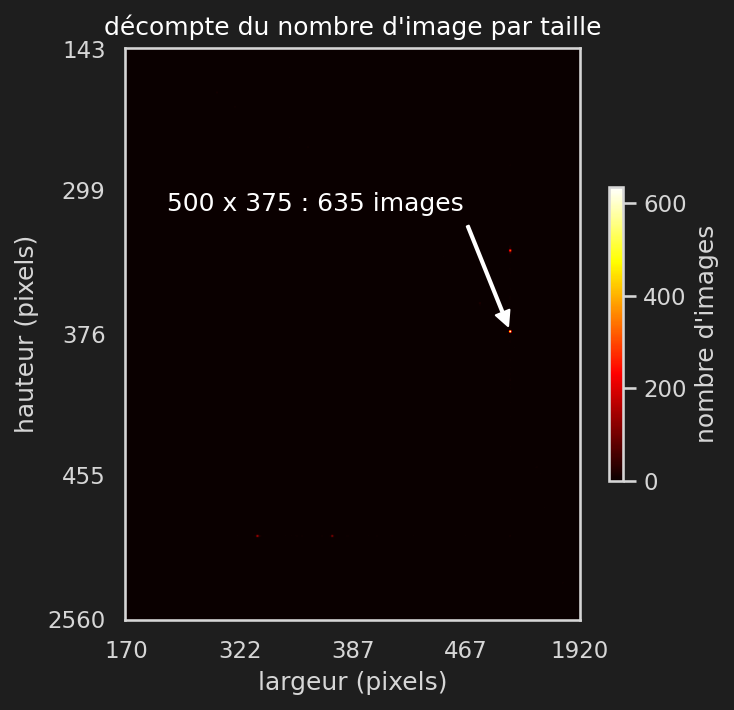

In [16]:
importlib.reload(funcs)
funcs.plot_image_shapes(infos)

In [17]:
target_shape = 224, 224
funcs.load_resize_crop_images(infos, path_data, path_data_save, target_shape)

100%   


In [18]:
importlib.reload(funcs)
funcs.create_annotations_files(infos, path_data_save)

,folder,n images
Maltese dog,n02085936-Maltese_dog,252
Afghan hound,n02088094-Afghan_hound,239
Scottish deerhound,n02092002-Scottish_deerhound,232
Pomeranian,n02112018-Pomeranian,219
Samoyed,n02111889-Samoyed,218
Bernese mountain dog,n02107683-Bernese_mountain_dog,218
Irish wolfhound,n02090721-Irish_wolfhound,218
Shih-Tzu,n02086240-Shih-Tzu,214
Great Pyrenees,n02111500-Great_Pyrenees,213
Leonberg,n02111129-Leonberg,210


train dataset: (1783, 2)
test dataset: (450, 2)
Nombre total d'images: 2233


,filename,label
1046,Bernese_mountain_dog/n02107683_1468.pt,5
1099,Bernese_mountain_dog/n02107683_5204.pt,5
498,Scottish_deerhound/n02092002_6534.pt,2
1700,Leonberg/n02111129_4903.pt,9
714,Pomeranian/n02112018_2691.pt,3
655,Pomeranian/n02112018_627.pt,3
988,Bernese_mountain_dog/n02107683_342.pt,5
1174,Irish_wolfhound/n02090721_552.pt,6
1164,Irish_wolfhound/n02090721_1003.pt,6
1548,Great_Pyrenees/n02111500_6045.pt,8


,filename,label
146,Pomeranian/n02112018_4554.pt,3
332,Shih-Tzu/n02086240_1366.pt,7
45,Maltese_dog/n02085936_8658.pt,0
213,Samoyed/n02111889_3471.pt,4
228,Samoyed/n02111889_774.pt,4
233,Samoyed/n02111889_13603.pt,4
262,Bernese_mountain_dog/n02107683_2567.pt,5
365,Great_Pyrenees/n02111500_7655.pt,8
387,Great_Pyrenees/n02111500_8729.pt,8
53,Afghan_hound/n02088094_13907.pt,1


Nombre de classes dans le dataset: 10
Nombre de classes dans le dataset: 10
image type: <class 'torch.Tensor'> tensor(249, device='cuda:0', dtype=torch.uint8)
label: tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]) argmax: 0


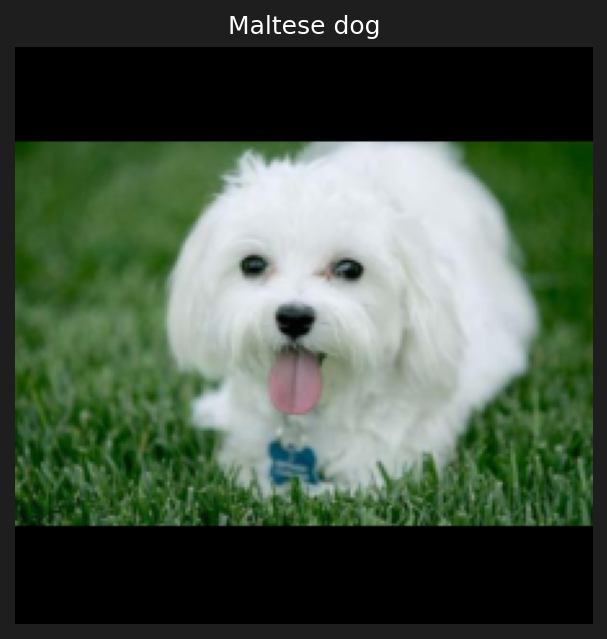

In [19]:
importlib.reload(funcs)
    
# one hot encoding transformer
train_data = funcs.CustomImageDataset('train', path_data_save)
test_data = funcs.CustomImageDataset('test', path_data_save)

funcs.test_class_dataset(train_data)

In [ ]:
train_dataloader = DataLoader(train_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

# Modélisation

In [ ]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")
if device == 'cuda':
    print(torch.cuda.get_device_name(torch.cuda.current_device()))

In [ ]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)
print(model)

In [ ]:
X = torch.rand(1, 28, 28, device=device)
logits = model(X)
pred_probab = nn.Softmax(dim=1)(logits)
y_pred = pred_probab.argmax(1)
print(f"Predicted class: {y_pred}")

In [ ]:
print(f"Model structure: {model}\n\n")

for name, param in model.named_parameters():
    print(f"Layer: {name} | Size: {param.size()} | Values : {param[:2]} \n")